# Exploratory Data Analysis (EDA)

## Objective

Understand the structure of the stock dataset before feature engineering.

Dataset:
RELIANCE_NS.csv

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
BASE_DIR = Path.cwd().parent

DATA_PATH = BASE_DIR / "data" / "raw" / "RELIANCE_NS.csv"

df = pd.read_csv(DATA_PATH)

In [3]:
df.head()

,Price,Adj Close,Close,High,Low,Open,Volume
0,Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
1,Date,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-07-06,962.3599853515625,980.5948486328125,991.7169799804688,978.4719848632812,989.8941040039062,10070124
3,2021-07-07,955.679443359375,973.7877197265625,981.956298828125,968.2266845703125,981.956298828125,10454892
4,2021-07-08,947.7760009765625,965.7345581054688,976.9721069335938,960.3811645507812,976.9721069335938,11185460


In [4]:
df.shape

(1240, 7)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1240 entries, 0 to 1239
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Price      1240 non-null   str  
 1   Adj Close  1239 non-null   str  
 2   Close      1239 non-null   str  
 3   High       1239 non-null   str  
 4   Low        1239 non-null   str  
 5   Open       1239 non-null   str  
 6   Volume     1239 non-null   str  
dtypes: str(7)
memory usage: 67.9 KB


In [6]:
df.describe()

,Price,Adj Close,Close,High,Low,Open,Volume
count,1240,1239,1239,1239,1239,1239,1239
unique,1240,1203,1183,1132,1136,1058,1235
top,Ticker,1267.2559814453125,1464.824951171875,1306.0,1151.442138671875,1420.0,0
freq,1,3,4,4,4,6,5


In [7]:
df.columns

Index(['Price', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

## EDA Part 2 — Price and Volume Trend Analysis

### Objective

Understand the historical behaviour of each stock's closing price, adjusted closing price, and trading volume through visual trend analysis.

This section uses the cleaned datasets from `ml/data/interim/` (produced by `clean_data.py`) rather than the raw files, so all stocks share a consistent, standardized schema.


In [8]:
BASE_DIR = Path.cwd().parent
INTERIM_DATA_DIR = BASE_DIR / "data" / "interim"
FIGURES_DIR = BASE_DIR / "reports" / "figures"

stock_data = {}

for filepath in sorted(INTERIM_DATA_DIR.glob("*.csv")):
    ticker = filepath.stem
    stock_data[ticker] = pd.read_csv(filepath, parse_dates=["Date"])

list(stock_data.keys())


['BHARTIARTL_NS',
 'HDFCBANK_NS',
 'ICICIBANK_NS',
 'INFY_NS',
 'ITC_NS',
 'LT_NS',
 'RELIANCE_NS',
 'SBIN_NS',
 'TCS_NS',
 'WIPRO_NS']

### 1. Closing Price Trend

**Objective:** Plot the Closing Price of every stock over time on a single figure.

**Why this visualization is useful:** A shared closing-price timeline makes it possible to see each stock's overall price trajectory at a glance and compare how different stocks have moved relative to one another over the same period.


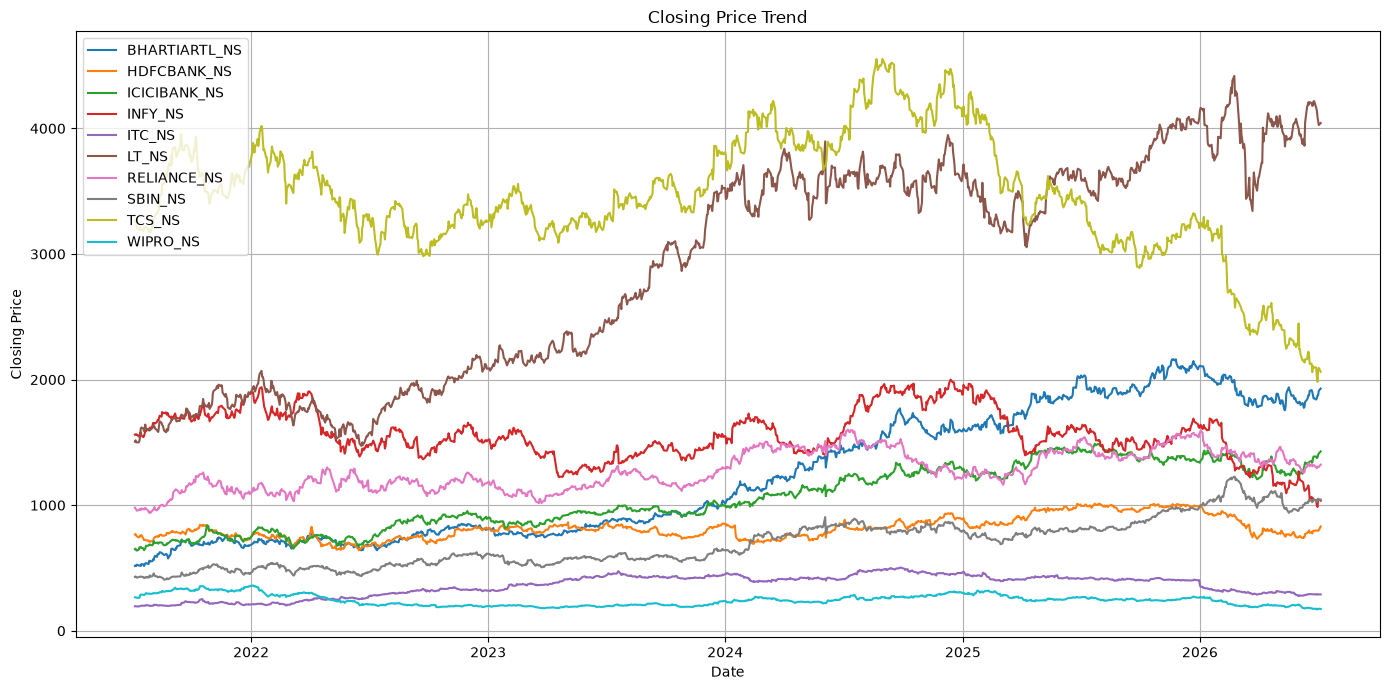

In [9]:
plt.figure(figsize=(14, 7))

for ticker, df in stock_data.items():
    plt.plot(df["Date"], df["Close"], label=ticker)

plt.title("Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "closing_price_trend.png")
plt.show()


### 2. Adjusted Closing Price Trend

**Objective:** Plot the Adjusted Closing Price of every stock over time on a single figure.

**Why this visualization is useful:** Adjusted Close accounts for corporate actions such as dividends and stock splits, so plotting it alongside the raw Closing Price provides a more consistent basis for comparing long-term price trends across stocks.


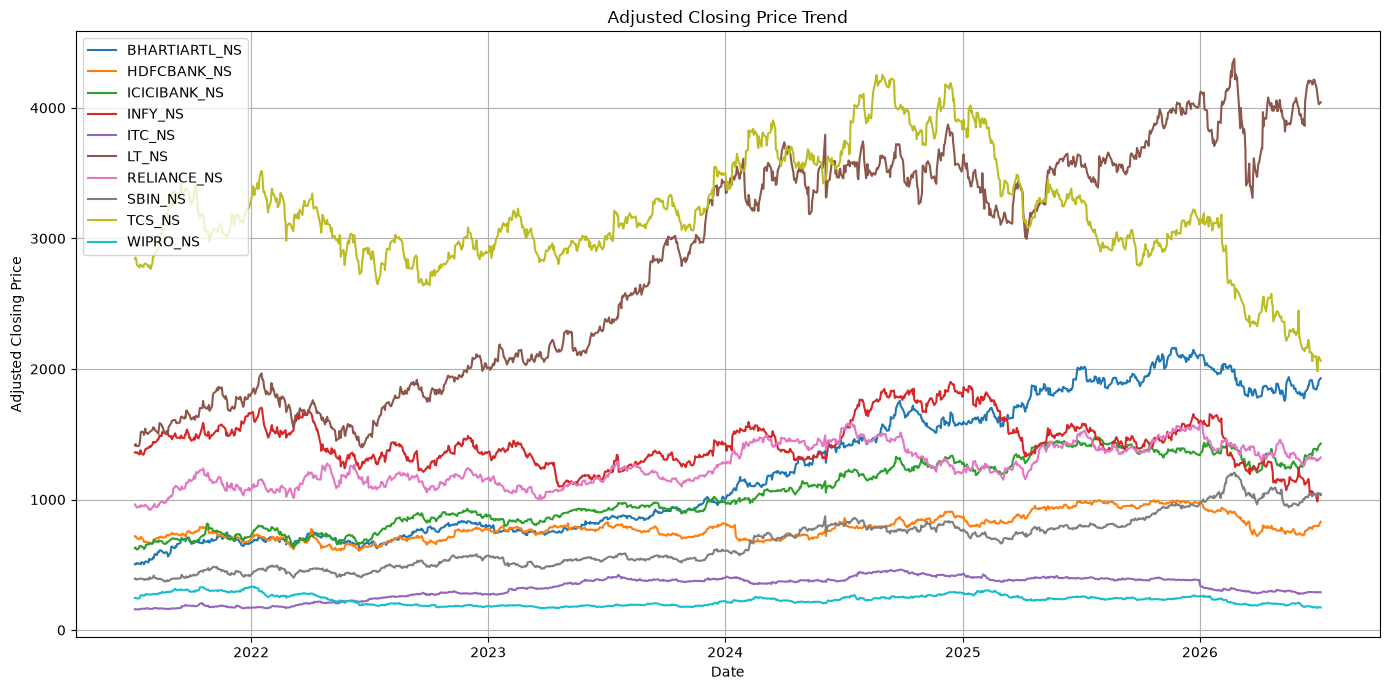

In [10]:
plt.figure(figsize=(14, 7))

for ticker, df in stock_data.items():
    plt.plot(df["Date"], df["Adj Close"], label=ticker)

plt.title("Adjusted Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Adjusted Closing Price")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "adjusted_close_trend.png")
plt.show()


### 3. Trading Volume Trend

**Objective:** Plot the Trading Volume of every stock over time on a single figure.

**Why this visualization is useful:** Volume reflects trading activity and liquidity; viewing it across all stocks on a shared timeline highlights how active each stock has been and lays the groundwork for later liquidity- or activity-based analysis.


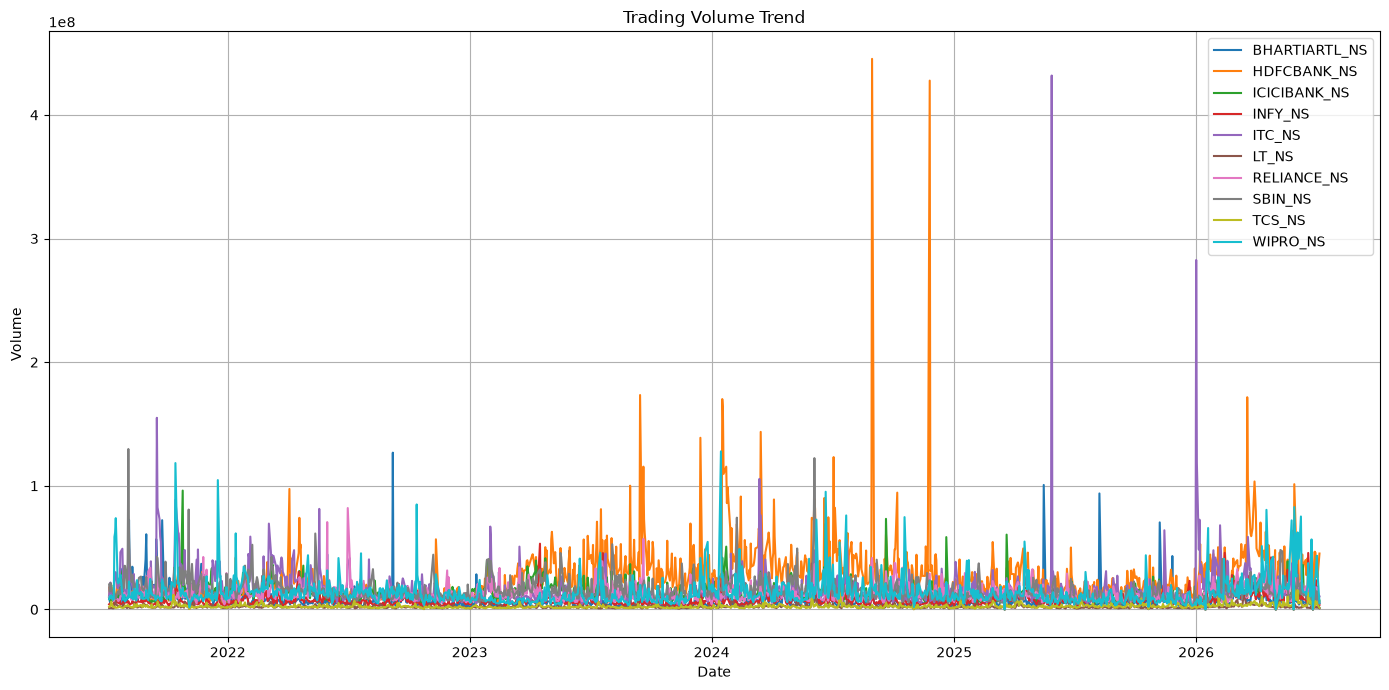

In [11]:
plt.figure(figsize=(14, 7))

for ticker, df in stock_data.items():
    plt.plot(df["Date"], df["Volume"], label=ticker)

plt.title("Trading Volume Trend")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "volume_trend.png")
plt.show()
